In [1]:
cd res/

/home/lowen/Documents/github/physics-of-agents/res


In [2]:
# Trajectory archetypes from data/clean_runs.json: individual trajectories
# (per-agent flip classes) and group trajectories (per-society band classes).
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from utils import (MODELS, REGIMES, TAU, IND_CLASSES, GRP_CLASSES, load_data,
                   opinions, flip_counts, individual_archetypes, group_archetypes)

runs, banks, P, GCLASS = load_data()

# Compute each run's mean opinion \bar{o}_i
for r in runs:
    # opinions: Computes the mean opinion of each agent over the last 5 rounds of the simulation.
    r["opinions"] = opinions(r)  # (9 rounds, 32 agents), k=5-resample means
print(len(runs), "societies")

9604 societies


In [4]:
matches = [
    (i, r)
    for i, r in enumerate(runs)
    if r.get("statement") == "Student loan debt should be forgiven by the government"
    and r.get("model") == "qwen3.6-plus-preview-free"
]

print("Matches:", len(matches))

for i, r in matches:
    print(i, r.get("model"), r.get("mode"), r.get("statement"))

Matches: 1
9602 qwen3.6-plus-preview-free subjective Student loan debt should be forgiven by the government


In [5]:
r = runs[9602]

print("Statement:", r["statement"])
print("\nPersonas:")
for i, p in enumerate(r.get("personas", [])):
    print(f"Agent {i}: {p}")

print("\nJ:")
for row in r["J"]:
    print(row)

print("\nOpinion history:")
for t, spins in enumerate(r["spins_history"]):
    print(f"Round {t}: {spins}")

print("\nMessages:")
for t, messages in enumerate(r.get("messages_history", [])):
    print(f"\n--- Round {t} ---")
    for sender_receiver, message in messages.items():
        print(sender_receiver, ":", message)

Statement: Student loan debt should be forgiven by the government

Personas:

J:
[0, 0, 0, -1]
[0, 0, -1, 0]
[0, -1, 0, 1]
[-1, 0, 1, 0]

Opinion history:
Round 0: [0, 0, 0, 0]
Round 1: [0, 0, 0, 0]
Round 2: [0, 0, 0, 0]

Messages:


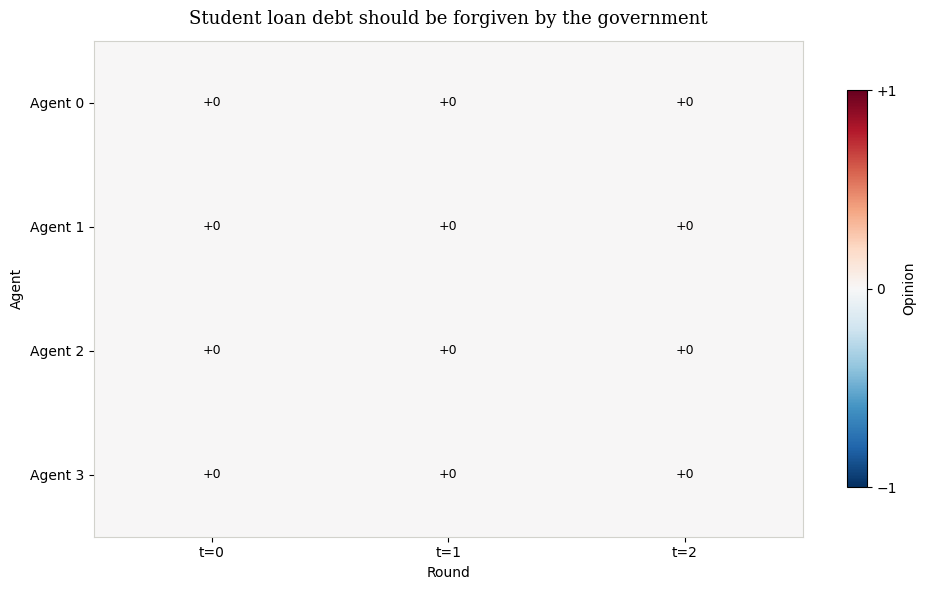

In [6]:
import numpy as np
import matplotlib.pyplot as plt

opinions = np.asarray(r["spins_history"])

# opinions shape: (rounds, agents)
T, N = opinions.shape

fig, ax = plt.subplots(figsize=(10, 6))

# Sort agents by their final opinion
order = np.argsort(-opinions[-1])

# Agents x rounds
data = opinions.T[order]

im = ax.imshow(
    data,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

# X axis
ax.set_xticks(
    range(T),
    [f"t={t}" for t in range(T)]
)

# Y axis
ax.set_yticks(
    range(N),
    [f"Agent {i}" for i in order]
)

ax.set_xlabel("Round")
ax.set_ylabel("Agent")

ax.set_title(
    r["statement"],
    fontsize=13,
    family="serif",
    pad=12
)

# Add values inside cells
for i in range(N):
    for t in range(T):
        value = data[i, t]

        if value > 0:
            text_color = "white"
        else:
            text_color = "black"

        ax.text(
            t,
            i,
            f"{value:+.0f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Opinion")

cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["−1", "0", "+1"])

# Borders
for s in ax.spines.values():
    s.set_color("#d2d2cc")

plt.tight_layout()
plt.show()